<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/Deep_Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MonteCarlo Off-Policy

*Description*: En este notebook se desarrolla la implementación del método de **Monte Carlo Off-Policy**, y se emplea sobre el entorno Frozen Lake de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/20


Empezamos instalando e importando las librerías necesarias. También definimos los dispositivos donde se ejecutará el notebook y la semilla que vamos a usar para asegurar reproducibilidad.

In [1]:
%%capture
!pip install 'gym[box2d]==0.20.0'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc
import os

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


gc.collect()              # Ejecuta el recolector de basura de Python
if torch.cuda.is_available():
    torch.cuda.empty_cache()   # Limpia la caché de la GPU


SEED = 123

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

Usando dispositivo: cpu


## Agente


Para implementar los distintos métodos de aprendizaje estudiados en la asignatura, hemos seguido las recomendaciones de Gymnasium para la creación de agentes y la generación de episodios, tal como se indicaba en la definición de la práctica. La idea central ha sido encapsular toda la lógica de interacción y aprendizaje en una clase `Agente`, adaptable a los diferentes algoritmos que se desean evaluar.

En este trabajo nos centramos en **Monte Carlo On-Policy**. Partimos de la versión proporcionada en el notebook `MonteCarloTodasLasVisitas.ipynb`, que servía como guía inicial, pero que no implementaba completamente la metodología de Monte Carlo. El motivo principal era la forma en que se actualizaban los valores $Q(S,A)$. En Monte Carlo, la actualización de cada par estado-acción debe realizarse al final del episodio usando los retornos específicos desde ese estado, $G_t$, siguiendo la regla:

$$
Q(S_t, A_t) \gets Q(S_t, A_t) + \alpha (G_t - Q(S_t, A_t))
$$

En cambio, en el notebook original se aplicaba la actualización usando el retorno total del episodio $G_0$, lo que rompía la correspondencia entre cada estado-acción y su retorno real, y por tanto no era una verdadera técnica Monte Carlo.

En cuanto a las políticas implementadas, el agente sigue varias políticas. Una **Epsilon-soft** que asigna una mínima probabilidad a todas las acciones, garantizando que nunca se deje de explorar, y una **Epsilon-greedy** que combina explotación de la acción con mayor valor esperado con exploración aleatoria, manteniendo un equilibrio entre ambos objetivos. Además, se usa una política **Greedy** estrictamente explotadora al final del entrenamiento para evaluar la capacidad de aprendizaje del agente.


El aprendizaje se basa en la **iteración de valores Monte Carlo**:

- Los valores $Q(S,A)$ se actualizan al finalizar cada episodio, no durante su ejecución.  
- La versión implementada es **on-policy**, de modo que la política que mejora el agente es la misma que utiliza para explorar.  
- Se aplica el criterio de **todas las visitas**, actualizando el valor de cada par estado-acción cada vez que es visitado dentro de un episodio.  
- La actualización se realiza **en orden inverso**, comenzando por las últimas visitas y avanzando hacia las primeras, siguiendo la metodología descrita por Sutton y Barto.


In [4]:
# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

class MonteCarloOnPolicyAgent:

    def __init__(self, env: gym.Env, epsilon: float, use_decay: bool, gamma: float):
        self.env = env
        self.eps = epsilon
        self.use_decay = use_decay
        self.gamma = gamma

        self.n_actions = env.action_space.n
        self.n_states = env.observation_space.n

        self.q_table = np.zeros((self.n_states, self.n_actions))
        self.n_visits = np.zeros((self.n_states, self.n_actions))
        self.history_returns = {}

    def get_q_values(self):
        return self.q_table

    def log_return(self, state, action, g_value):
        key = (state, action)
        if key not in self.history_returns:
            self.history_returns[key] = []
        self.history_returns[key].append(g_value)

    def get_return(self, state, action):
        return self.history_returns[(state, action)]

    # --- Gestión de Políticas ---

    # Política uniforme
    def get_action_uniform(self, state):
        return np.random.choice(np.arange(self.n_actions))

    def get_uniform_policy(self, state):
        return np.ones(self.n_actions) / self.n_actions

    # Política epsilon-soft. Se usa para el entrenamiento
    def random_epsilon_greedy_policy(self, state):
        pi_A = np.ones(self.n_actions, dtype=float) * self.eps / self.n_actions
        best_action = np.argmax(self.q_table[state])
        pi_A[best_action] += (1.0 - self.eps)
        return pi_A

    # Política epsilon-greedy a partir de una epsilon-soft
    def epsilon_greedy_policy(self, state):
        pi_A = self.random_epsilon_greedy_policy(state)
        return np.random.choice(np.arange(self.n_actions), p=pi_A)

    # Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
    def pi_star_from_Q(self, env):
        done = False
        pi_star = np.zeros([env.observation_space.n, env.action_space.n])
        state, info = env.reset() # start in top-left, = 0
        actions = ""
        while not done:
            action = np.argmax(self.q_table[state, :])
            actions += f"{action}, "
            pi_star[state,action] = action
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        return pi_star, actions


    def update_knowledge(self, episode_data):
        g_return = 0.0

        # Iterar el episodio desde el final hacia el principio
        for s, a, r in reversed(episode_data):
            g_return = r + self.gamma * g_return

            self.n_visits[s,a] = self.n_visits[s,a] + 1

            self.q_table[s, a] += (1.0/self.n_visits[s,a]) * (g_return - self.q_table[s, a])

        return g_return

## Esquema de aprendizaje

Ahora implementamos el proceso de aprendizaje basándonos en el código disponible en el notebook del profesor, cambiando obviamente lo necesario para que la implementación de Monte Carlo sea correcta.

La función `on_policy_all_visit` implementa un aprendizaje Monte Carlo On-Policy considerando todas las visitas de cada episodio. Para cada episodio, el agente genera una trayectoria completa siguiendo su política $\epsilon$-greedy, ajustando $\epsilon$ si se aplica decay, y registra todas las transiciones `(estado, acción, recompensa)`. Al final del episodio, se calculan los retornos y se actualizan los valores de la función de valor de manera incremental. Además, se guarda la longitud de cada episodio y la recompensa acumulada promedio para monitorizar la evolución del aprendizaje y la convergencia de la política.

In [5]:
def on_policy_all_visit(agente, num_episodes=5000):

    # Número de visitas. Vamoa a realizar la versión incremental.
    #n_visits = np.zeros([env.observation_space.n, env.action_space.n])

    # Para mostrar la evolución en el terminal y algún dato que mostrar
    stats = 0.0
    list_stats = [stats]
    step_display = num_episodes / 10

    longitudes = []

    for t in tqdm(range(num_episodes)):
        state, info = agente.env.reset(seed=SEED)
        done = False
        episode = []
        result_sum = 0.0  # Retorno
        while not done:
            if agente.use_decay:
                agente.eps = min(agente.eps, 1000.0/(t+1))

            action = agente.epsilon_greedy_policy(state)
            new_state, reward, terminated, truncated, info = agente.env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = new_state

        result_sum = agente.update_knowledge(episode)


        # Guardamos datos sobre la evolución. Promedio de recompensas
        stats += result_sum
        longitudes.append(len(episode))
        list_stats.append(stats/(t+1))


        # Para mostrar la evolución.  Comentar si no se quiere mostrar
        if t % step_display == 0 and t != 0:
            print(f"success: {stats/t}, epsilon: {agente.eps}")

    return longitudes, list_stats

## Funciones auxiliares

Ahora vamos a definir una serie de funciones auxiliares que nos van a servir para mostrar resultados y realizar el análisis.

La primera función que definimos la usaremos una vez entrenado el agente, de forma que podamos evaluar el aprendizaje llevado a cabo.

In [6]:
def capture_optimal_behavior(agente, limit_steps=100):
    """
    Graba un episodio completo siguiendo la política óptima del agente
    y devuelve las métricas de rendimiento junto con los frames de video.
    """
    visual_frames = []
    current_state, _ = agente.env.reset(seed=SEED)

    accumulated_reward = 0.0
    steps_count = 0
    is_finished = False

    while not is_finished and steps_count < limit_steps:
        # 1. Capturar el estado visual actual
        img_frame = agente.env.render()
        visual_frames.append(img_frame)

        # 2. Decidir acción basada en la política objetivo (greedy)
        chosen_action = np.argmax(agente.get_q_values()[current_state, :])

        # 3. Ejecutar transición en el entorno
        next_s, reward, terminated, truncated, _ = agente.env.step(chosen_action)

        # 4. Actualizar contadores y estado
        accumulated_reward += reward
        current_state = next_s
        steps_count += 1
        is_finished = terminated or truncated

    # Capturar el último frame tras el fin del episodio
    visual_frames.append(agente.env.render())
    agente.env.close()

    return accumulated_reward, steps_count, visual_frames

Las siguiente funciones mostrarán las gráficas de aprendizaje y longitud de los episodios una vez realizado el aprendizaje de los agentes.

La longitud del episodio es un medidor de rendimiento interesante porque no solo indica si el agente alcanza la meta, sino también **cómo de eficiente es la política aprendida**. En entornos donde existe una ruta óptima, la convergencia hacia un número estable y bajo de pasos suele reflejar que el agente ha aprendido un comportamiento estructurado y cercano al óptimo.

Además, esta métrica permite interpretar mejor los resultados: episodios muy cortos pueden indicar caídas tempranas en estados terminales negativos, mientras que episodios largos pueden reflejar exploración excesiva o movimientos erráticos. Por ello, la longitud del episodio complementa a la recompensa promedio y ayuda a entender no solo si el agente aprende, sino **cómo está aprendiendo**.

In [7]:
def draw_multiple_learning_curves(results_dict):
    """
    Representa varias curvas de entrenamiento en el mismo gráfico.

    results_dict:
        Diccionario donde:
        clave -> nombre experimento/agente
        valor -> lista con historial de métricas
    """

    first_key = next(iter(results_dict))
    x_axis = np.arange(len(results_dict[first_key]))

    fig, ax = plt.subplots(figsize=(10, 4))

    for experiment_name, history in results_dict.items():
        ax.plot(x_axis, history, label=experiment_name)

    ax.set_title("Comparativa de rendimiento")
    ax.set_xlabel("Número de episodio")
    ax.set_ylabel("Valor medio")
    ax.legend()

    ax.grid()
    plt.show()


def compute_running_mean(series, window):
    """
    Calcula un suavizado tipo media deslizante sobre una serie temporal.
    """
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")


def draw_episode_length_trend(length_history):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    # Señal original (transparente)
    ax.plot(length_history, alpha=0.25, color="forestgreen")

    # Tendencia suavizada
    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    ax.set_title("Evolución del tamaño de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        # Señal original
        ax.plot(values, alpha=0.2, color=color)

        # Tendencia suavizada
        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    ax.set_title("Comparativa de longitudes de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

Las siguientes funciones servirán para visualizar los resultados con imágenes y gifs del comportamiento del agente.

In [8]:
import seaborn as sns
import imageio
import base64
from IPython.display import HTML
import matplotlib.pyplot as plt

def map_qtable_to_directions(q_table, grid_size):
    """
    Genera dos matrices a partir de la Q-table:
      1. Valores máximos de Q por estado.
      2. Flechas representando la mejor acción por estado.

    Parámetros:
      - q_table (np.array): Tabla Q (num_states x num_actions)
      - grid_size (int): Tamaño del mapa (map_size x map_size)

    Retorna:
      - q_max_values (np.array): Valores Q máximos por estado
      - q_directions (np.array): Flechas con la mejor acción por estado
    """

    # Valores máximos y acciones óptimas
    q_max_values = q_table.max(axis=1).reshape(grid_size, grid_size)
    best_actions = np.argmax(q_table, axis=1).reshape(grid_size, grid_size)

    # Diccionario de flechas
    arrow_map = {0: "←", 1: "↓", 2: "→", 3: "↑"}

    # Inicializamos la matriz de direcciones como vacía
    q_directions = np.empty(best_actions.size, dtype=str)

    # Valor mínimo positivo para evitar asignar flechas a estados sin información
    min_val = np.finfo(float).eps

    # Recorremos los estados y asignamos flechas solo si el valor Q > eps
    for idx, action in enumerate(best_actions.flatten()):
        if q_max_values.flatten()[idx] > min_val:
            q_directions[idx] = arrow_map[action]

    # Reestructuramos a la forma del mapa
    q_directions = q_directions.reshape(grid_size, grid_size)

    return q_max_values, q_directions

def visualize_q_policy(q_table, grid_size):
    """
    Muestra un heatmap con los valores Q aprendidos
    y la acción óptima por estado.
    """

    # Transformar Q-table en valores máximos y flechas de dirección
    max_vals, best_actions = map_qtable_to_directions(q_table, grid_size)

    plt.figure(figsize=(7, 6))

    ax = sns.heatmap(
        max_vals,
        annot=best_actions,
        fmt="",
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=False,
        yticklabels=False,
        annot_kws={"fontsize": "xx-large"}
    )

    ax.set_title("Valores Q aprendidos\nFlechas indican mejor acción")

    # Mostrar bordes
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")

    plt.show()



def create_gif_from_frames(frame_list, output_path="frozenlake_agent.gif"):
    """
    Genera un GIF animado a partir de una lista de imágenes.

    Parámetros:
      - frame_list (list): Lista de frames capturados del entorno.
      - output_path (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Ruta del GIF creado.
    """
    with imageio.get_writer(output_path, mode="I") as gif_writer:
        for frame in frame_list:
            gif_writer.append_data(frame)
    return output_path


def show_gif_in_notebook(gif_file_path):
    """
    Inserta un GIF en una celda de Jupyter Notebook o Colab.

    Parámetros:
      - gif_file_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML para mostrar el GIF.
    """
    with open(gif_file_path, "rb") as f:
        gif_bytes = f.read()

    b64_str = base64.b64encode(gif_bytes).decode("utf-8")
    return HTML(f'<img src="data:image/gif;base64,{b64_str}" />')

## Entorno Frozen Lake

A continuación, creamos el entorno "Frozen Lake" de Gymnasium con el que trabajaremos.

In [9]:
def creacion_entorno(env_name, map="4x4", render = "ansi", slippery=False, max_episode_steps=100):
  env = gym.make(env_name, is_slippery=slippery, map_name=map, render_mode=render, max_episode_steps=max_episode_steps)
  env.reset(seed=SEED) # Establece la semilla en el entorno de Gymnasium
  return env

In [10]:
env4x4 = creacion_entorno('FrozenLake-v1', "4x4", "rgb_array")

Ahora creamos los diferentes agentes que usaremos. Con el objetivo de analizar el impacto del nivel inicial de exploración y del uso de mecanismos de decaimiento en la probabilidad de exploración, se han definido seis agentes basados en el algoritmo Monte Carlo On-Policy, todos ellos evaluados en el entorno Frozen Lake 4x4.

Se han considerado tres valores iniciales del parámetro $\epsilon$:

- **$\epsilon$ = 0.2** → exploración baja  
- **$\epsilon$ = 0.4** → exploración moderada  
- **$\epsilon$ = 0.6** → exploración relativamente alta

Estos valores permiten cubrir un espectro amplio de comportamientos exploratorios, desde una política relativamente cercana a la explotación hasta una política puramente aleatoria.

Para cada valor de $\epsilon$ se han definido dos configuraciones adicionales, uno con epsilon decay y otro sin decay. Con decay, la probabilidad de exploración disminuye progresivamente según el esquema  

$$
\epsilon_t = \min\left(\epsilon_0, \frac{1000}{t+1}\right)
$$

lo que favorece una transición gradual desde exploración hacia explotación.

En todos los casos se fija el factor de descuento en **$\gamma = 0.99**, con el objetivo de mantener constante la importancia otorgada a recompensas futuras y aislar exclusivamente el efecto del nivel de exploración y su evolución temporal.

Este diseño permite estudiar:

- La influencia del nivel inicial de exploración en la velocidad de aprendizaje.
- El efecto del decaimiento en la convergencia de la política objetivo.
- La posible interacción entre exploración intensa inicial y transición progresiva hacia explotación.


In [11]:
agent_02_decay = MonteCarloOnPolicyAgent(env4x4, epsilon=0.2, use_decay=True, gamma=0.99)
agent_02_nodecay = MonteCarloOnPolicyAgent(env4x4, epsilon=0.2, use_decay=False, gamma=0.99)
agent_04_decay = MonteCarloOnPolicyAgent(env4x4, epsilon=0.4, use_decay=True, gamma=0.99)
agent_04_nodecay = MonteCarloOnPolicyAgent(env4x4, epsilon=0.4, use_decay=False, gamma=0.99)
agent_06_decay = MonteCarloOnPolicyAgent(env4x4, epsilon=0.6, use_decay=True, gamma=0.99)
agent_06_nodecay = MonteCarloOnPolicyAgent(env4x4, epsilon=0.6, use_decay=False, gamma=0.99)


In [12]:
n_episodes = 50000

list_len, list_stats = on_policy_all_visit(agent_02_decay, n_episodes)

 10%|█         | 5045/50000 [00:17<02:41, 279.07it/s]

success: 0.0, epsilon: 0.19996000799840033


 21%|██        | 10395/50000 [00:24<00:17, 2205.70it/s]

success: 0.2718210511463762, epsilon: 0.0999900009999


 31%|███       | 15445/50000 [00:26<00:15, 2265.12it/s]

...

 81%|████████  | 40391/50000 [00:38<00:04, 2356.33it/s]

success: 0.7455535589384034, epsilon: 0.02499937501562461


 91%|█████████ | 45304/50000 [00:40<00:02, 2268.13it/s]

success: 0.7657877392867289, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:43<00:00, 1142.63it/s]


In [13]:
list_len2, list_stats2 = on_policy_all_visit(agent_02_nodecay, n_episodes)

 10%|█         | 5055/50000 [00:15<02:07, 353.73it/s]

success: 0.0, epsilon: 0.2


 21%|██        | 10309/50000 [00:23<00:17, 2213.37it/s]

success: 0.20173885777704623, epsilon: 0.2


 30%|███       | 15238/50000 [00:26<00:25, 1362.87it/s]

...

 80%|████████  | 40190/50000 [00:38<00:06, 1405.87it/s]

success: 0.6019626937531222, epsilon: 0.2


 91%|█████████ | 45349/50000 [00:40<00:02, 2165.94it/s]

success: 0.6170233489015648, epsilon: 0.2


100%|██████████| 50000/50000 [00:43<00:00, 1160.04it/s]


In [14]:
list_len3, list_stats3 = on_policy_all_visit(agent_04_decay, n_episodes)

 11%|█         | 5349/50000 [00:03<00:21, 2037.00it/s]

success: 0.5225619198670706, epsilon: 0.19996000799840033


 21%|██        | 10449/50000 [00:05<00:17, 2301.86it/s]

success: 0.6668792533039313, epsilon: 0.0999900009999


 31%|███       | 15361/50000 [00:07<00:15, 2227.66it/s]

...

 81%|████████  | 40337/50000 [00:19<00:04, 2326.17it/s]

success: 0.8456318574708815, epsilon: 0.02499937501562461


 91%|█████████ | 45324/50000 [00:21<00:02, 2317.48it/s]

success: 0.8547155445405208, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:24<00:00, 2042.52it/s]


In [15]:
list_len4, list_stats4 = on_policy_all_visit(agent_04_nodecay, n_episodes)

 10%|█         | 5235/50000 [00:03<00:32, 1388.11it/s]

success: 0.46435169230368945, epsilon: 0.4


 21%|██        | 10405/50000 [00:06<00:18, 2119.11it/s]

success: 0.48287047319736176, epsilon: 0.4


 30%|███       | 15211/50000 [00:08<00:16, 2050.13it/s]

...

 81%|████████  | 40269/50000 [00:29<00:06, 1490.86it/s]

success: 0.5032063954161694, epsilon: 0.4


 91%|█████████ | 45324/50000 [00:31<00:02, 2088.42it/s]

success: 0.5022828144270999, epsilon: 0.4


100%|██████████| 50000/50000 [00:34<00:00, 1461.90it/s]


In [16]:
list_len5, list_stats5 = on_policy_all_visit(agent_06_decay, n_episodes)

 10%|█         | 5090/50000 [00:06<01:23, 536.54it/s]

success: 0.4255712418173559, epsilon: 0.19996000799840033


 20%|██        | 10094/50000 [00:14<01:01, 652.83it/s]

success: 0.5649915590788278, epsilon: 0.0999900009999


 31%|███       | 15489/50000 [00:23<00:15, 2260.00it/s]

...

 81%|████████  | 40433/50000 [00:36<00:04, 2274.62it/s]

success: 0.8061283468835113, epsilon: 0.02499937501562461


 90%|█████████ | 45105/50000 [00:39<00:02, 1915.77it/s]

success: 0.8198475140418626, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:42<00:00, 1179.29it/s]


In [17]:
list_len6, list_stats6 = on_policy_all_visit(agent_06_nodecay, n_episodes)

 11%|█         | 5300/50000 [00:02<00:22, 1995.29it/s]

success: 0.2721844671887766, epsilon: 0.6


 21%|██        | 10300/50000 [00:05<00:20, 1952.33it/s]

success: 0.27097501963880016, epsilon: 0.6


 31%|███       | 15381/50000 [00:07<00:16, 2108.89it/s]

...

 81%|████████  | 40384/50000 [00:21<00:04, 2122.57it/s]

success: 0.2683719889135685, epsilon: 0.6


 90%|█████████ | 45209/50000 [00:24<00:03, 1408.52it/s]

success: 0.2682618654117812, epsilon: 0.6


100%|██████████| 50000/50000 [00:26<00:00, 1876.45it/s]


## Resultados en el caso 4x4

Guardamos los resultados obtenidos en diccionarios para pasárselos a las funciones auxiliares definidas anteriormente para plotear los resultados.

In [18]:
dict_stats = {'eps=0.2, decay=True': list_stats, 'eps=0.2, decay=False': list_stats2, 'eps=0.4, decay=True': list_stats3, 'eps=0.4, decay=False': list_stats4, 'eps=0.6, decay=True': list_stats5, 'eps=0.6, decay=False': list_stats6}
dict_len = {'eps=0.2, decay=True': list_len, 'eps=0.2, decay=False': list_len2, 'eps=0.4, decay=True': list_len3, 'eps=0.4, decay=False': list_len4, 'eps=0.6, decay=True': list_len5, 'eps=0.6, decay=False': list_len6}

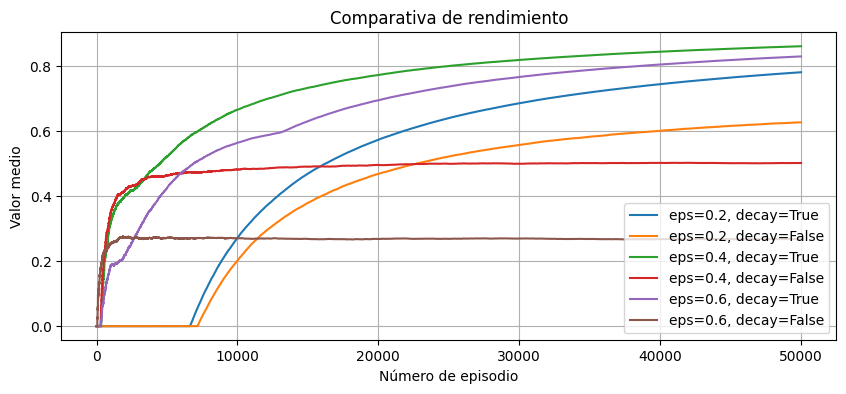

In [19]:
draw_multiple_learning_curves(dict_stats)

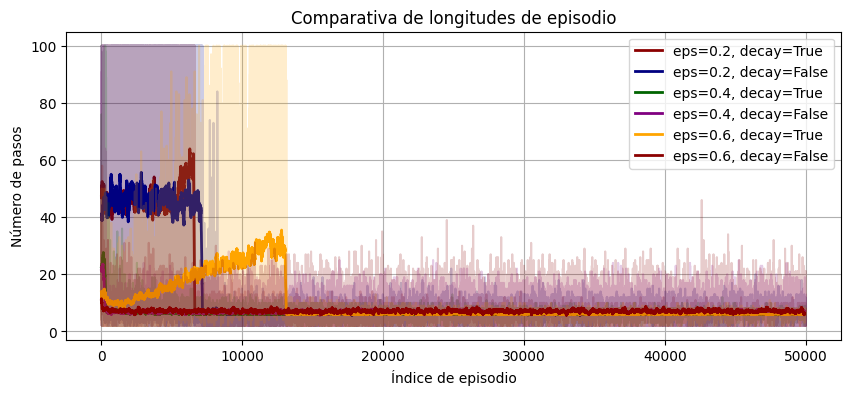

In [20]:
draw_episode_length_comparison(dict_len)

A simple vista, parece que todos los agentes terminan estabilizando la duración de los episodios en valores relativamente bajos. Sin embargo, esta aparente convergencia no implica necesariamente que hayan aprendido una política óptima, sino que puede deberse simplemente a que los episodios finalizan rápidamente al caer en estados no deseados. Por tanto, es fundamental analizar ambas gráficas de forma conjunta, ya que si observamos únicamente la evolución de las longitudes de los episodios podríamos extraer conclusiones incompletas.

Al contrastar esta información con la gráfica de rendimiento medio, se aprecian diferencias mucho más claras entre configuraciones. En los casos donde se emplea decaimiento de $\epsilon$, el rendimiento crece de forma sostenida y alcanza valores significativamente superiores. Esto indica que, tras una fase inicial de exploración, el agente comienza a explotar la información aprendida y consigue alcanzar la meta con mayor frecuencia. En particular, el valores de $\epsilon=0.7$ con decaimiento muestran una mejora rápida en las primeras etapas y una convergencia estable posterior, obteniendo el mejor resultado en la gráfica de rendimiento. Esto parece indicar que 0.7 es un valor que equilibra la exploración inicial con la explotación.

Por el contrario, cuando no se utiliza decaimiento, el comportamiento es notablemente peor, especialmente para valores altos de $\epsilon$. En estos casos, aunque las longitudes de los episodios también parecen estabilizarse, el rendimiento medio permanece bajo o crece muy lentamente. Esto refleja que el agente continúa explorando en exceso durante todo el entrenamiento, sin consolidar una política efectiva. El caso de $\epsilon=1.0$ sin decaimiento es el más representativo: la exploración es completamente aleatoria y el rendimiento apenas mejora, lo que confirma que una exploración constante y extrema impide la convergencia hacia la política óptima. En el caso de este entorno Frozen Lake, seguramente esto se deba a que el agente se cae continuamente en los agujeros del mapa.

En conclusión, el análisis conjunto pone de manifiesto que no basta con observar la reducción en la longitud de los episodios para afirmar que el aprendizaje ha sido exitoso. Es el rendimiento medio el que realmente confirma si el agente está alcanzando la meta de manera consistente. Los resultados muestran claramente que incorporar decaimiento en $\epsilon$ es clave para lograr una política eficaz, mientras que mantener un nivel fijo y alto de exploración limita seriamente el desempeño del agente.

Ahora vamos a visualizar la política aprendida, usando las funciones auxiliares que muestran visualmente la política y generan gifs con el comportamiento del agente.

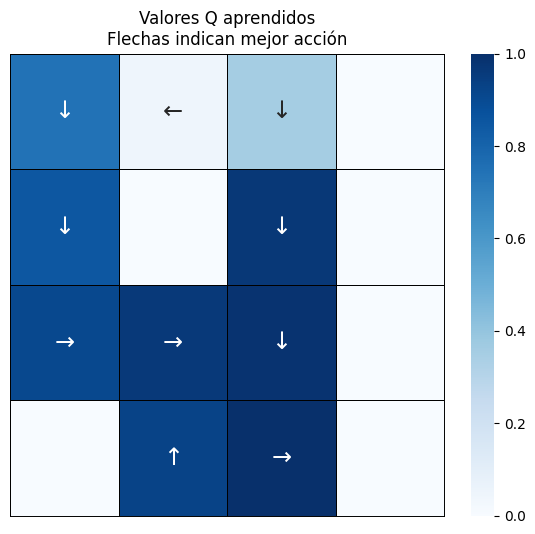

In [21]:
env4x4.reset(seed=SEED)
visualize_q_policy(agent_02_decay.get_q_values(), 4)

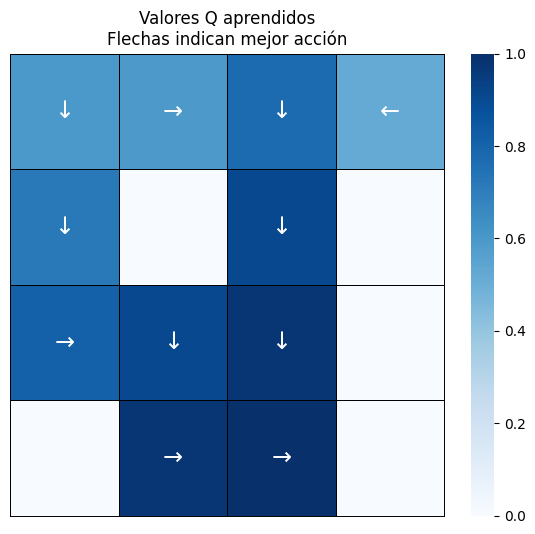

In [22]:
env4x4.reset(seed=SEED)
visualize_q_policy(agent_02_nodecay.get_q_values(), 4)

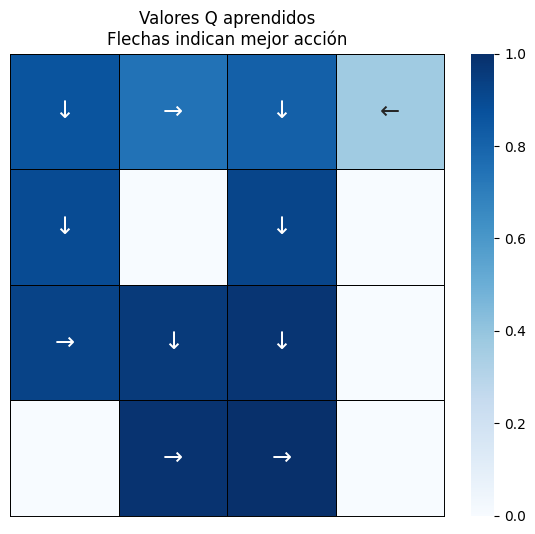

In [23]:
env4x4.reset(seed=SEED)
visualize_q_policy(agent_04_decay.get_q_values(), 4)

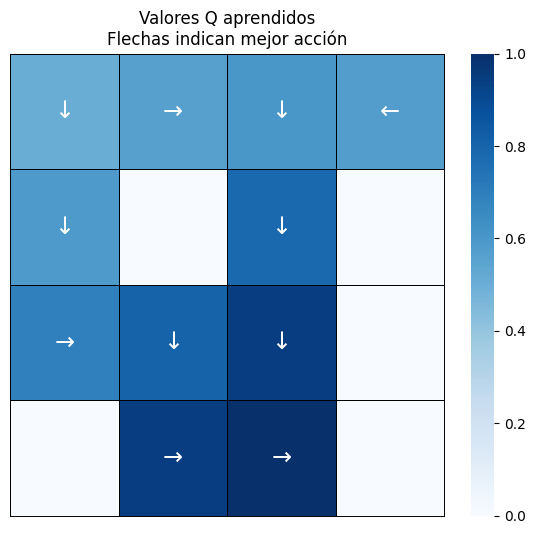

In [24]:
env4x4.reset(seed=SEED)
visualize_q_policy(agent_04_nodecay.get_q_values(), 4)

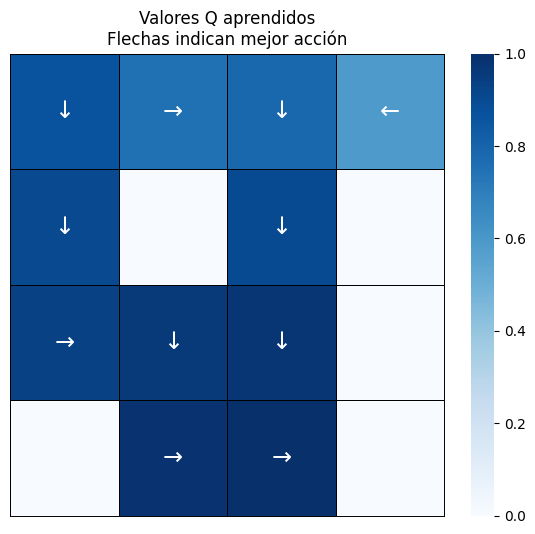

In [25]:
env4x4.reset(seed=SEED)
visualize_q_policy(agent_06_decay.get_q_values(), 4)

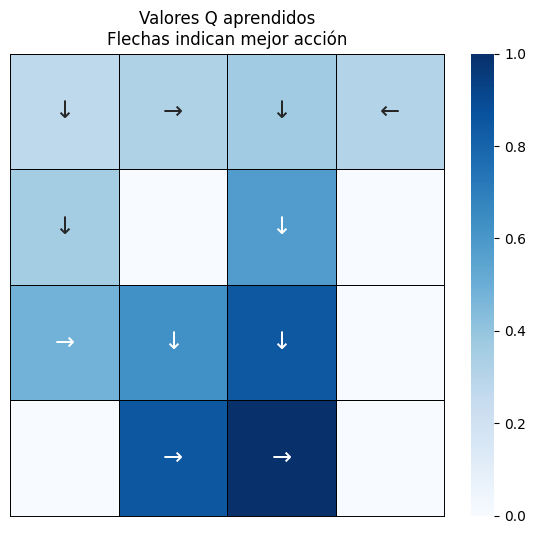

In [26]:
env4x4.reset(seed=SEED)
visualize_q_policy(agent_06_nodecay.get_q_values(), 4)

Vemos cómo mostrar estos gráficos visuales es interesante pero no proporciona excesiva información. Se observa que en general la mejor acción tiene sentido en todos los casos. Es cierto que en los casos sin decay, que ya vimos que eran los que peor rendimiento obtuvieron, se observan posiciones en las que el mejor movimiento no es correcto o no tiene tanta seguridad, como es el caso de la segunda celda de la primera fila en el caso de epsilon 0.3 sin decay. Quitando estos casos, todos obtienen resultados parecidos, aunque si que parece que cuanto mejor es el caso, más seguridad hay en las acciones. No obstante las diferencias son pequeñas.

Debido a todo esto, vamos a generar un gif con el comportameinto de la política obtenida en el mejor caso, epsilon 0.7 con decay.

Guardado en: MCP_EP4D_FL.gif



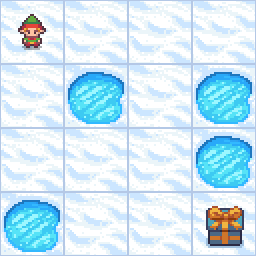

In [27]:
# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
reward, len_episode, frames = capture_optimal_behavior(agent_04_decay)

# Crear el GIF a partir de los fotogramas capturados.
path = create_gif_from_frames(frames, "MCP_EP4D_FL.gif")
print("Guardado en:", path)

show_gif_in_notebook(path)

Ahora vamos a dejar el epsilon fijo, dejándolo en 0.7 debido a que fue el agente que mejor resultado obtuvo, y con decay activado. Vamos entonces a variar el otro parámetro, el gamma (factor de descuento).

El objetivo de este experimento es estudiar cómo afecta la consideración de recompensas futuras al proceso de aprendizaje. Recordemos que este parámetro controla el peso relativo entre recompensas inmediatas y recompensas a largo plazo:

- Valores bajos de gamma favorecen estrategias más miopes, priorizando recompensas cercanas.
- Valores altos de gamma fomentan políticas más planificadas, al dar mayor importancia a recompensas futuras.

Este análisis permite comprender hasta qué punto el rendimiento del agente depende del horizonte temporal considerado durante la actualización de los valores Q.

Definimos los agentes con gamma 0.9 y 0.95 (el de 0.99 ya lo teníamos antes) y ejecutamos los entrenamientos.

In [ ]:
agent_07_decay3 = MonteCarloOffPolicyAgent(env4x4, epsilon=0.7, use_decay=True, gamma=0.9)
agent_07_decay4 = MonteCarloOffPolicyAgent(env4x4, epsilon=0.7, use_decay=True, gamma=0.95)


In [ ]:
list_len8, list_stats8 = on_policy_all_visit(agent_07_decay3, n_episodes)

 10%|█         | 5242/50000 [00:02<00:23, 1897.68it/s]

success: 0.3114494641800058, epsilon: 0.19996000799840033


 20%|██        | 10013/50000 [00:07<01:18, 510.30it/s]

success: 0.42315421599000974, epsilon: 0.0999900009999


 30%|███       | 15214/50000 [00:11<00:25, 1340.29it/s]

...

 81%|████████  | 40290/50000 [00:26<00:05, 1884.72it/s]

success: 0.5371538249473315, epsilon: 0.02499937501562461


 90%|█████████ | 45249/50000 [00:29<00:02, 1779.66it/s]

success: 0.5424185820197164, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:32<00:00, 1530.20it/s]


In [ ]:
list_len9, list_stats9 = on_policy_all_visit(agent_07_decay4, n_episodes)

 11%|█         | 5283/50000 [00:03<00:27, 1606.48it/s]

success: 0.3585671855737636, epsilon: 0.19996000799840033


 21%|██        | 10325/50000 [00:06<00:21, 1843.06it/s]

success: 0.5157692802025104, epsilon: 0.0999900009999


 30%|███       | 15204/50000 [00:08<00:19, 1803.74it/s]

...

 80%|████████  | 40174/50000 [00:23<00:07, 1349.01it/s]

success: 0.6881144499429191, epsilon: 0.02499937501562461


 90%|█████████ | 45212/50000 [00:26<00:02, 1942.56it/s]

success: 0.6960072107367052, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:29<00:00, 1720.27it/s]


Vamos a ver los resultados.

In [ ]:
dict_stats3 = {'gamma=0.9': list_stats8, 'gamma=0.95': list_stats9, 'gamma=0.99': list_stats3}
dict_len3 = {'gamma=0.9': list_len8, 'gamma=0.95': list_len9, 'gamma=0.99': list_len3}

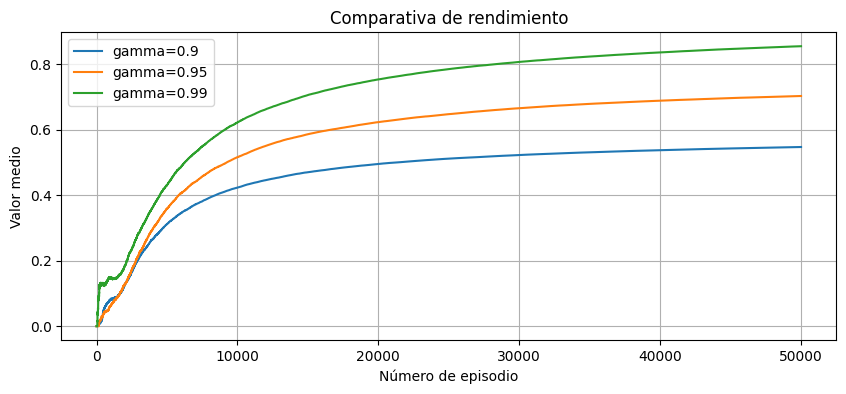

In [ ]:
draw_multiple_learning_curves(dict_stats3)

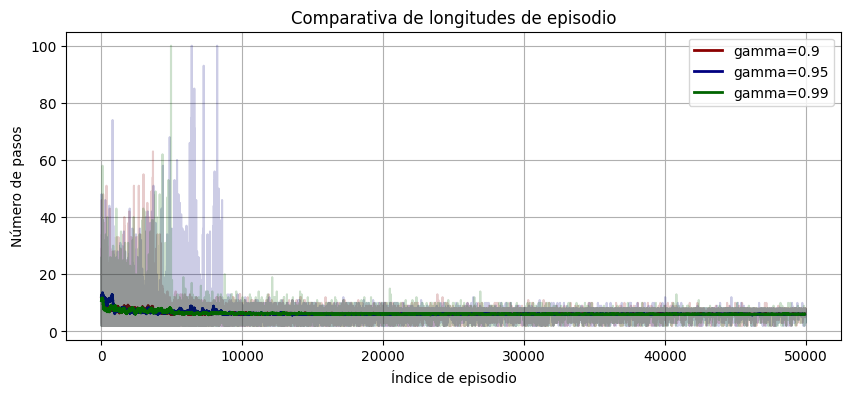

In [ ]:
draw_episode_length_comparison(dict_len3)

Observamos que la longitud de los episodios disminuye muy rápidamente, estando siempre muy baja. Pero lo más interesante se observa en la comparativa de rendimiento. Vemos cómo conforme disminuye el valor de gamma el rendimiento también disminuye. Estos resultados muestran claramente la importancia del factor de descuento en la valoración de recompensas futuras. Con valores altos de gamma, el agente considera de manera más significativa las recompensas lejanas, lo que le permite planificar trayectorias completas hacia el objetivo y alcanzar un rendimiento superior. Por el contrario, con gamma más bajos, el agente se centra en recompensas inmediatas y tiende a tomar decisiones miope, lo que explica la disminución del rendimiento observado.

## Caso Frozen Lake 8x8

A modo de experimentación, debido a que el entorno Frozen Lake tiene la opción de ser de tamaño 8x8 en lugar de 4x4, vamos a probar qué tal funciona el mejor agente del caso anterior en este entorno de tamaño mayor. Usaremos entonces un agente con epsilon 0.7 y con decay.

Creamos el entorno y el agente, y ejecutamos el aprendizaje.

In [ ]:
env8x8 = creacion_entorno('FrozenLake-v1', "8x8", "rgb_array")

agent_07_decay2 = MonteCarloOffPolicyAgent(env8x8, epsilon=0.7, use_decay=True, gamma=0.99)

#Ejecutamos el aprendizaje
list_len7, list_stats7 = on_policy_all_visit(agent_07_decay2, n_episodes)


 10%|█         | 5030/50000 [00:28<04:32, 164.80it/s]

success: 0.0, epsilon: 0.19996000799840033


 20%|██        | 10035/50000 [01:03<04:03, 164.33it/s]

success: 0.0, epsilon: 0.0999900009999


 30%|███       | 15028/50000 [01:38<03:47, 153.85it/s]

...

 80%|████████  | 40025/50000 [04:42<01:11, 139.81it/s]

success: 0.0, epsilon: 0.02499937501562461


 90%|█████████ | 45024/50000 [05:20<00:34, 145.11it/s]

success: 0.0, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [05:58<00:00, 139.58it/s]


Vamos a ver los resultados.

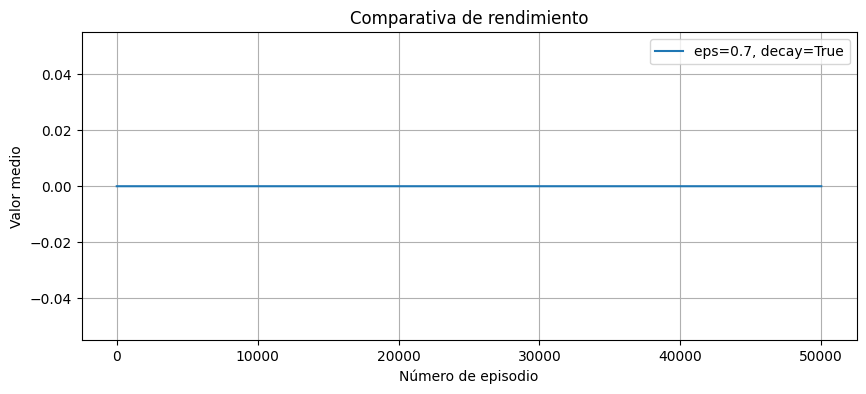

In [ ]:
dict_stats2 = {'eps=0.7, decay=True': list_stats7}
dict_len2 = {'eps=0.7, decay=True': list_len7}

draw_multiple_learning_curves(dict_stats2)

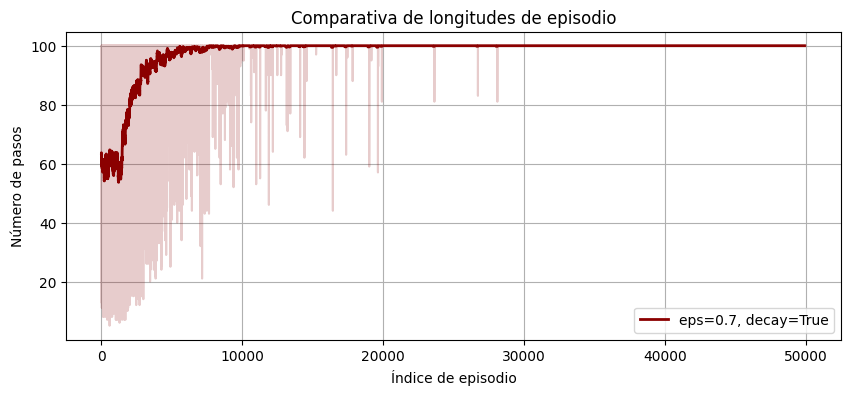

In [ ]:
draw_episode_length_comparison(dict_len2)

Los resultados, como se puede observar, son nefastos. El incremento de complejidad que ha supuesto aumentar el tamaño del grid de Frozen Lake ha hecho que el agente haya sido incapaz de aprender.

## Posibles mejoras y líneas de Investigación Futuras

**Exploración en entornos más complejos:** Sería interesante aplicar los agentes Monte Carlo Off-Policy a entornos de Gym más desafiantes para evaluar cómo se adapta la política de exploración y cómo influye el tamaño del espacio de estados en la eficiencia del aprendizaje. Aunque en este notebook probamos con Frozen Lake 8x8 que mostró ser claramente más desafiante, convendría probar con más casos complicados.

**Variaciones en el decaimiento de epsilon:** Se ha utilizado un esquema inversamente proporcional para el decaimiento de epsilon, pero se podría estudiar la influencia de otros métodos de decaimiento.

**Análisis más profundo del factor de descuento gamma:** En este trabajo se han probado distintos valores de gamma para un epsilon seleccionado, pero se podrían explorar combinaciones adicionales para entender mejor la interacción entre la planificación a largo plazo y la exploración inicial.